# Evaluación Parcial N°1 - SCY1101 Programación para la Ciencia de Datos

**Dataset:** `Food_Preference.csv`

**Integrantes:** Milenka Guerra - Fabián Quiñones

## 0. Importación de librerías y configuraciones del entorno

In [1]:
# Análisis y manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Imputación, encoders, escaladores y pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Ignorar alertas de deprecados
import warnings
warnings.filterwarnings("ignore")

# Configuración del entorno
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Carga y Exploración Inicial

### 1.1 Revisión general del DataSet

In [2]:
# Carga del dataset
df = pd.read_csv("../data/raw/Food_Preference_raw.csv")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones del dataset: 290 filas x 8 columnas


In [3]:
# Visualización de las primeras filas del dataset
df.head(5)

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.00,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.00,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.00,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.00,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.00,Traditional food,Fresh Juice,Maybe


In [4]:
# Tabla de resumen: Variables, Tipos, NAs
# Esta tabla da una visión rápida consolidada de la calidad de los datos del dataset
tabla_datos = pd.DataFrame(
    {
        "Variable": df.columns,
        "Tipo de Dato": df.dtypes.astype(str),
        "Cantidad de NAs": df.isna().sum(),
        "% NAs": (df.isna().sum() / len(df) * 100).round(2),
        "Únicos": df.nunique(),
    }
).reset_index(drop=True)

display(tabla_datos)

,Variable,Tipo de Dato,Cantidad de NAs,% NAs,Únicos
0,Timestamp,str,0,0.00,285
1,Participant_ID,str,0,0.00,288
2,Gender,str,6,2.07,5
3,Nationality,str,0,0.00,28
4,Age,float64,2,0.69,53
5,Food,str,0,0.00,7
6,Juice,str,0,0.00,2
7,Dessert,str,0,0.00,3


Escogimos revisar los datos creando una tabla, ya que permiten tener una visión más clara y ordenada en comparación a un `df.info()`, pudiendo agregar incluso columnas de información relevante como los conteos o cálculos de nulos y valores únicos.

In [5]:
# Para las variables numéricas creamos un pequeño DataFrame para calcular las estadísticas descriptivas
columnas_num = df.select_dtypes(include=["number"]).columns

estadisticas = pd.DataFrame(
    {
        "Media": df[columnas_num].mean(),
        "Mediana": df[columnas_num].median(),
        "Moda": df[columnas_num].mode().iloc[0],
        "Desviación Estándar": df[columnas_num].std(),
        "Varianza": df[columnas_num].var(),
        "Mínimo": df[columnas_num].min(),
        "Q1": df[columnas_num].quantile(0.25),
        "Q2": df[columnas_num].quantile(0.50),
        "Q3": df[columnas_num].quantile(0.75),
        "Máximo": df[columnas_num].max(),
        "Rango": df[columnas_num].max() - df[columnas_num].min(),
        "IQR": df[columnas_num].quantile(0.75) - df[columnas_num].quantile(0.25),
    }
)

display(estadisticas)

print("\n\n")

# Para variables categóricas utilizamos el método describe() con el parámetro include=["O"] (objects) para obtener las estadísticas relevantes:
display(df.describe(include=["O"]))

,Media,Mediana,Moda,Desviación Estándar,Varianza,Mínimo,Q1,Q2,Q3,Máximo,Rango,IQR
Age,31.62,28.00,25.00,20.84,434.44,-47.00,24.00,28.00,37.00,263.00,310.00,13.00


,Timestamp,Participant_ID,Gender,Nationality,Food,Juice,Dessert
count,290,290,284,290,290,290,290
unique,285,288,5,28,7,2,3
top,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,Traditional food,Fresh Juice,Maybe
freq,2,2,165,242,236,257,123


In [6]:
# Identificación de Nulos

# Definimos una función reutilizable para encontrar y mostrar valores nulos en un DataFrame
def encontrar_nulos_y_mostrar(df_datos):
    conteo_nulos = df_datos.isnull().sum()
    cols_nulas = conteo_nulos[conteo_nulos > 0]

    if cols_nulas.empty:
        print("No se encontraron valores nulos en el DataFrame.")
    else:
        # Crear un DataFrame para mostrar las variables con nulos y su conteo
        df_nulos = pd.DataFrame({
            'Variable': cols_nulas.index,
            'Conteo de Nulos': cols_nulas.values
        }).reset_index(drop=True)
        display(df_nulos)

# Llamamos a la función para identificar y mostrar los nulos en el df
encontrar_nulos_y_mostrar(df)

,Variable,Conteo de Nulos
0,Gender,6
1,Age,2


In [7]:
# Revisamos la existencia de registros duplicados

n_duplicados = df.duplicated().sum()
print(f"Registros duplicados encontrados: {n_duplicados}")

if n_duplicados > 0:
    print("Filas duplicadas:")
    display(df[df.duplicated(keep=False)])

Registros duplicados encontrados: 2
Filas duplicadas:


,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.00,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.00,Western Food,Carbonated drinks,Yes
101,2019/05/07 4:58:26 PM GMT+8,FPS101,Female,Indian,25.00,Traditional food,Fresh Juice,Maybe
102,2019/05/07 4:58:26 PM GMT+8,FPS101,Female,Indian,25.00,Traditional food,Fresh Juice,Maybe


### 1.2 Exploración de variables

A continuación, exploramos de forma más concisa cada columna, para poder identificar de cuáles obtenemos datos con valor para un futuro análisis, cuál es la calidad de los datos, cuáles son los outliers en las variables numéricas y las inconsistencias que pueden tener las variables categóricas.

In [8]:
# Para un primer panorama general buscamos inconsistencias en las variables categóricas
# Lo hacemos listando los valores únicos de cada columna
for col in ["Gender", "Nationality", "Food", "Juice", "Dessert"]:
    print(f"{col}:{sorted(df[col].dropna().unique())}")
    print()

Gender:['FEMALE', 'Femal', 'Female', 'MASCULINO', 'Male']

Nationality:[' ', 'Algerian ', 'Canadian', 'China', 'Indian', 'Indonesain', 'Indonesia', 'Indonesian', 'Indonesian ', 'Japan', 'Korean ', 'MALAYSIAN', 'MY', 'Malaysia', 'Malaysia ', 'Malaysian', 'Malaysian ', 'Maldivian', 'Maldivian ', 'Masculino', 'Mauritian', 'Nigerian ', 'Pakistan', 'Pakistani', 'Pakistani ', 'Seychellois', 'Tanzanian', 'Yemen']

Food:[' ', 'Traditional Food', 'Traditional food', 'Western Food', 'Western food', 'traditional food', 'western Food']

Juice:['Carbonated drinks', 'Fresh Juice']

Dessert:['Maybe', 'No', 'Yes']



#### Marca de Tiempo (`Timestamp`)

In [9]:
# Exploramos los valores de la columna 'Timestamp'
timestamp = df['Timestamp'].value_counts().reset_index()
timestamp.columns = ['Timestamp', 'Cantidad']
display(timestamp)

,Timestamp,Cantidad
0,2019/05/07 2:59:45 PM GMT+8,2
1,2019/05/07 3:07:36 PM GMT+8,2
2,2019/05/07 4:58:26 PM GMT+8,2
3,2019/05/08 1:16:11 AM GMT+8,2
4,2019/05/10 1:07:43 AM GMT+8,2
...,...,...
280,2019/05/10 9:24:00 AM GMT+8,1
281,2019/05/10 9:32:54 AM GMT+8,1
282,2019/05/10 12:09:17 PM GMT+8,1
283,2019/05/10 12:52:17 PM GMT+8,1


In [10]:
min_timestamp = df['Timestamp'].min()
max_timestamp = df['Timestamp'].max()

print(f"Fecha y hora más temprana: {min_timestamp}")
print(f"Fecha y hora más tardía: {max_timestamp}")

Fecha y hora más temprana: 2019/05/07 10:25:13 PM GMT+8
Fecha y hora más tardía: 2019/05/10 9:32:54 AM GMT+8


In [11]:
# Contar el número de timestamps únicos
unique_timestamps = df['Timestamp'].nunique()
print(f"Número de timestamps únicos: {unique_timestamps}")

Número de timestamps únicos: 285


#### ID de Participante (`Participant_ID`)

In [12]:
# Exploramos los valores de la columna 'Participant_ID'
# Lo realizamos en formato tabla debido a la cantidad de datos
part_id = df['Participant_ID'].value_counts().reset_index()
part_id.columns = ['Participant_ID', 'Cantidad']
display(part_id)

,Participant_ID,Cantidad
0,FPS002,2
1,FPS101,2
2,FPS001,1
3,FPS003,1
4,FPS004,1
...,...,...
283,FPS284,1
284,FPS285,1
285,FPS286,1
286,FPS287,1


In [13]:
# Contar el número de IDs de participante únicos
unique_participantes = df['Participant_ID'].nunique()
print(f"Número de participantes únicos: {unique_participantes}")

Número de participantes únicos: 288


#### Edad (`Age`)

In [14]:
# Identificamos si existen valores outliers utilizando el método IQR en la columna 'Age'
q1 = df["Age"].quantile(0.25)
q3 = df["Age"].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers_age = df[(df["Age"] < limite_inf) | (df["Age"] > limite_sup)]

print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Límites válidos: [{limite_inf:.1f}, {limite_sup:.1f}]")
print(f"Outliers en 'Age': {len(outliers_age)} registros")
display(outliers_age[["Participant_ID", "Age"]])

Q1=24.0, Q3=37.0, IQR=13.0
Límites válidos: [4.5, 56.5]
Outliers en 'Age': 13 registros


,Participant_ID,Age
21,FPS021,2.00
22,FPS022,200.00
42,FPS042,263.00
44,FPS044,60.00
59,FPS059,-47.00
66,FPS066,74.00
70,FPS070,80.00
74,FPS074,80.00
91,FPS091,60.00
140,FPS139,59.00


In [15]:
# Como es un dato Float, calculamos valores con decimal distinto a 0
df[df['Age'] % 1 != 0]['Age']

14   NaN
20   NaN
Name: Age, dtype: float64

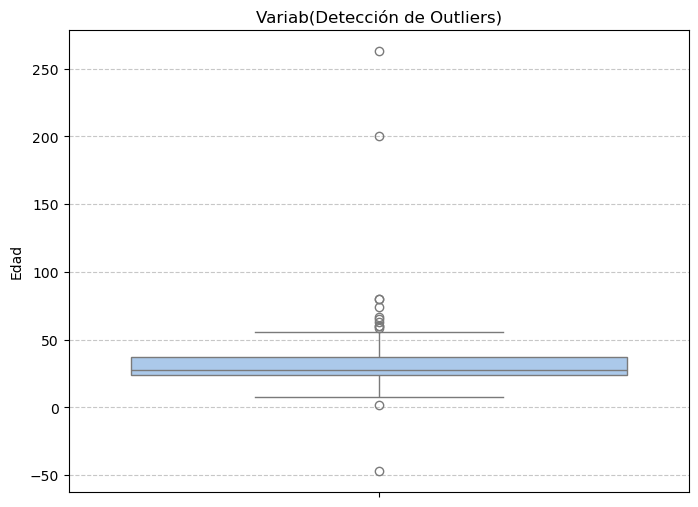

In [16]:
# Creamos un diagrama de caja para la columna 'Age' para visualizar los valores atípicos
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'], palette='pastel')
plt.title('Variab(Detección de Outliers)')
plt.ylabel('Edad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Tipo de comida (`Food`)

In [17]:
# Exploramos los valores de la columna 'Food'
print(f"Valores de 'Food': {df['Food'].unique()}\n")

# Y realizamos un conteo con cada preferencia alimentaria
pref_comida = df['Food'].value_counts().reset_index()
pref_comida.columns = ['Tipo de comida', 'Cantidad']
display(pref_comida)

Valores de 'Food': <StringArray>
['Traditional food',     'Western Food',     'Western food',
                ' ', 'Traditional Food',     'western Food',
 'traditional food']
Length: 7, dtype: str



,Tipo de comida,Cantidad
0,Traditional food,236
1,Western Food,49
2,Western food,1
3,,1
4,Traditional Food,1
5,western Food,1
6,traditional food,1


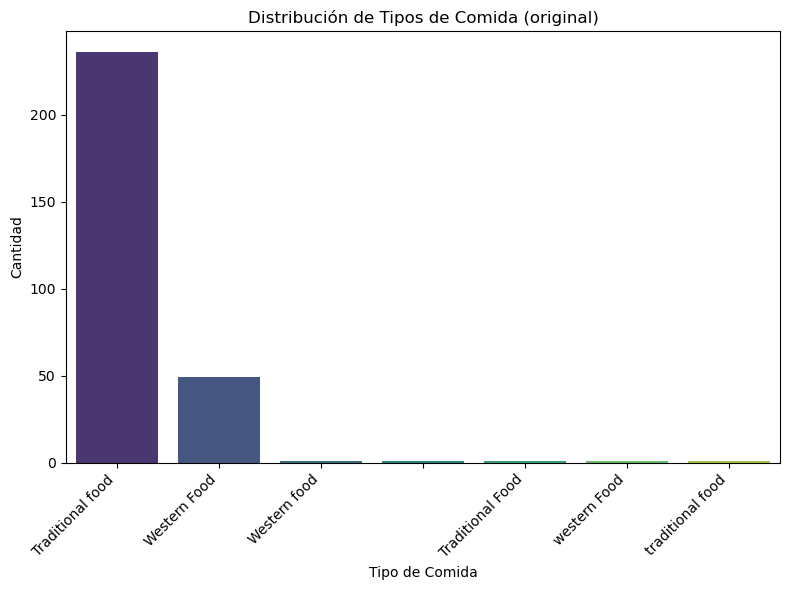

In [18]:
# Gráfico de barras para visualizar la distribución de preferencias alimentarias
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Food', palette='viridis')
plt.title('Distribución de Tipos de Comida (original)')
plt.xlabel('Tipo de Comida')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Género (`Gender`)

In [19]:
# Exploramos los valores de la columna 'Gender'
print(f"Valores de 'Gender': {df['Gender'].unique()}\n")

# Y realizamos un conteo para cada valor en 'Gender'
genero = df['Gender'].value_counts().reset_index()
genero.columns = ['Género', 'Cantidad']
display(genero)

Valores de 'Gender': <StringArray>
[nan, 'Female', 'Male', 'FEMALE', 'MASCULINO', 'Femal']
Length: 6, dtype: str



,Género,Cantidad
0,Female,165
1,Male,116
2,FEMALE,1
3,MASCULINO,1
4,Femal,1


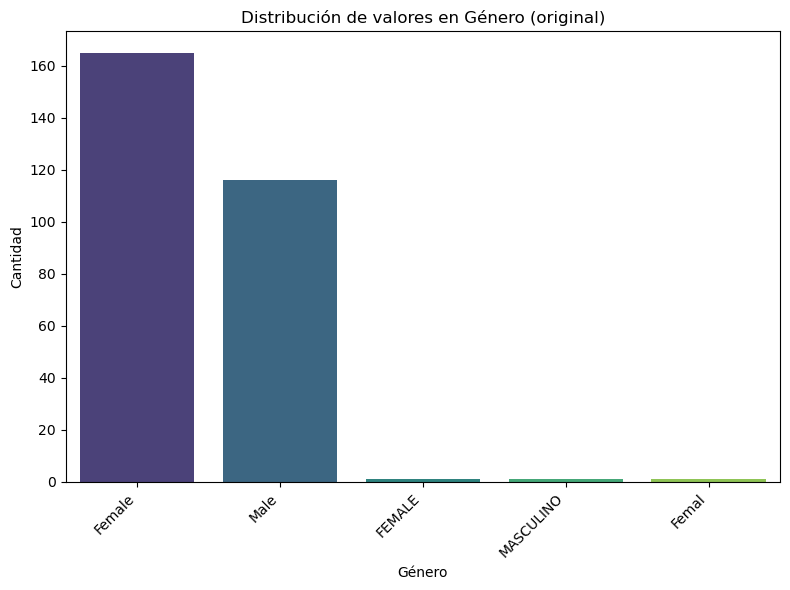

In [20]:
# Gráfico de barras para visualizar la distribución de género

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Gender', palette='viridis')
plt.title('Distribución de valores en Género (original)')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Nacionalidad (`Nationality`)

In [21]:
# Exploramos los valores de la columna
print(f"Valores de 'Nationality': {df['Nationality'].unique()}\n")

# Y realizamos un conteo para cada valor en Nationality
nacionalidad = df['Nationality'].value_counts().reset_index()
nacionalidad.columns = ['Nacionalidad', 'Cantidad']
display(nacionalidad)

Valores de 'Nationality': <StringArray>
[     'Indian',  'Pakistani ',   'Tanzanian',   'Indonesia',   'Masculino',
    'Pakistan',  'Maldivian ',          'MY',   'Malaysian',  'Malaysian ',
 'Indonesian ',   'Maldivian',   'MALAYSIAN',   'Malaysia ',   'Pakistani',
    'Canadian',   'Nigerian ',   'Algerian ',     'Korean ', 'Seychellois',
  'Indonesain',  'Indonesian',    'Malaysia',       'Japan',       'China',
   'Mauritian',           ' ',       'Yemen']
Length: 28, dtype: str



,Nacionalidad,Cantidad
0,Indian,242
1,Malaysian,10
2,Indonesia,7
3,Pakistani,3
4,Pakistani,2
5,MY,2
6,Maldivian,2
7,Japan,2
8,Tanzanian,1
9,Masculino,1


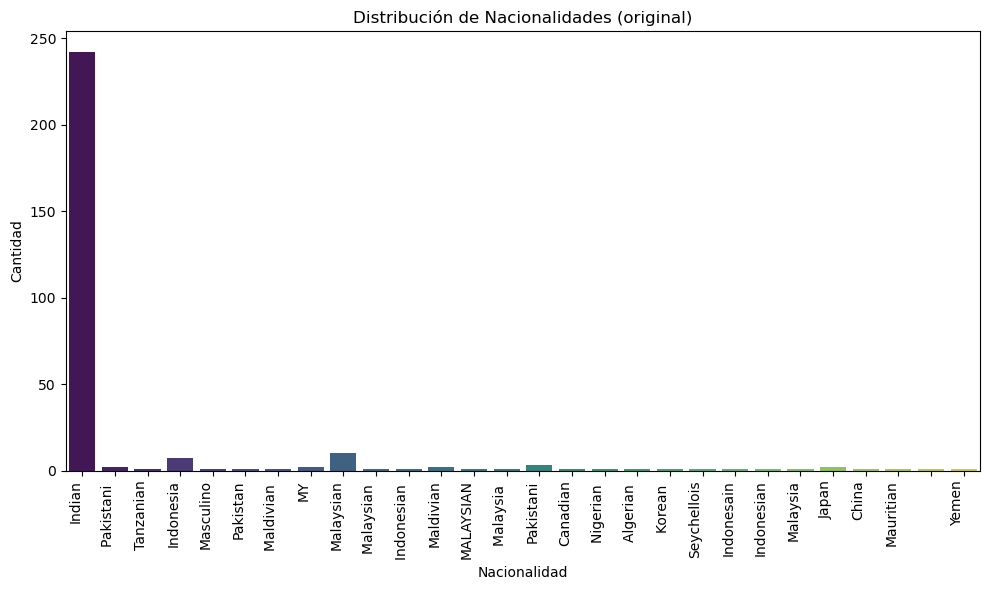

In [22]:
# Gráfico de barras para visualizar la distribución de nacionalidad

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Nationality', palette='viridis')
plt.title('Distribución de Nacionalidades (original)')
plt.xlabel('Nacionalidad')
plt.ylabel('Cantidad')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

#### Bebestible `Juice`

In [23]:
# Exploramos los valores de la columna
print(f"Valores de 'Juice': {df['Juice'].unique()}\n")

# Y realizamos un conteo para cada valor en Juice
bebestible = df['Juice'].value_counts().reset_index()
bebestible.columns = ['Tipo de Bebestible', 'Cantidad']
display(bebestible)

Valores de 'Juice': <StringArray>
['Fresh Juice', 'Carbonated drinks']
Length: 2, dtype: str



,Tipo de Bebestible,Cantidad
0,Fresh Juice,257
1,Carbonated drinks,33


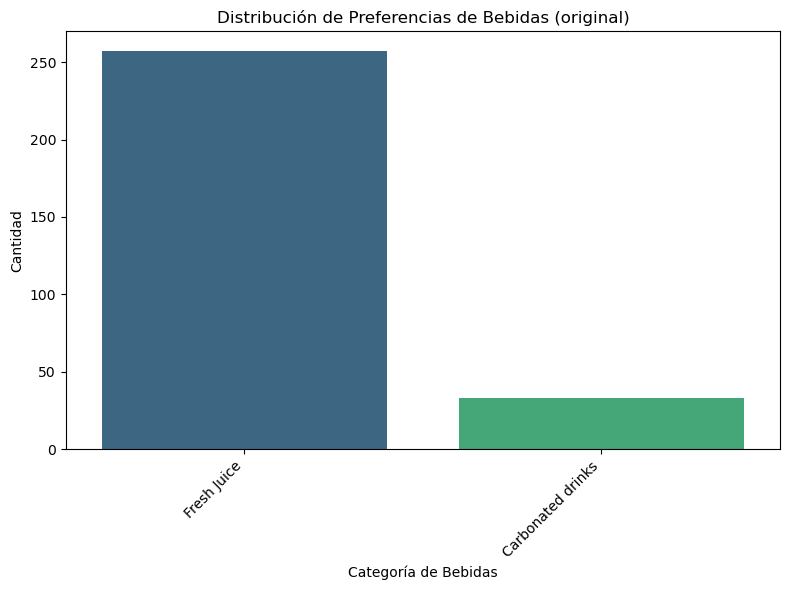

In [24]:
# Gráfico de barras para visualizar la distribución de las preferencias de bebestibles
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Juice', palette='viridis')
plt.title('Distribución de Preferencias de Bebidas (original)')
plt.xlabel('Categoría de Bebidas')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### `Dessert`

In [25]:
# Exploramos los valores de la columna
print(f"Valores de 'Dessert': {df['Dessert'].unique()}\n")

# Y realizamos un conteo para cada valor en Juice
postre = df['Dessert'].value_counts().reset_index()
postre.columns = ['Elección de Postre', 'Cantidad']
display(postre)

Valores de 'Dessert': <StringArray>
['Maybe', 'Yes', 'No']
Length: 3, dtype: str



,Elección de Postre,Cantidad
0,Maybe,123
1,Yes,115
2,No,52


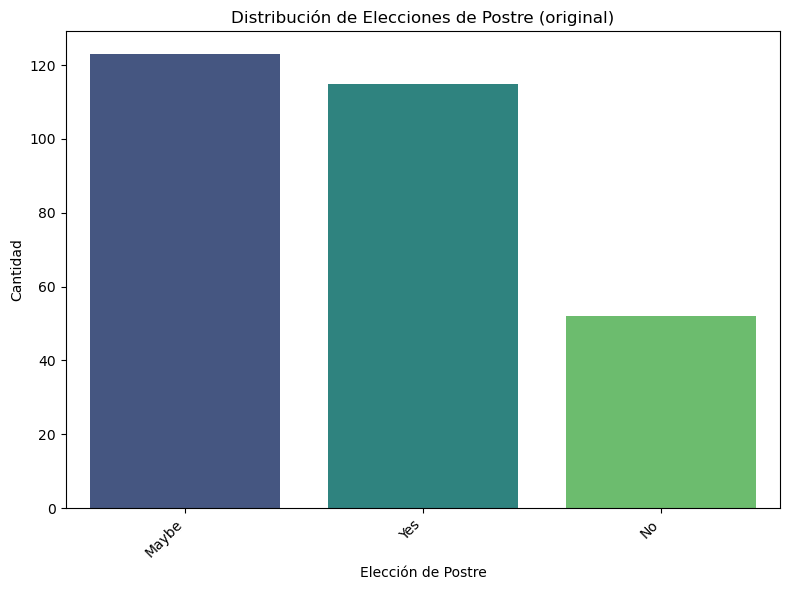

In [26]:
# Gráfico de barras para visualizar la distribución de las preferencias de bebestibles
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Dessert', palette='viridis')
plt.title('Distribución de Elecciones de Postre (original)')
plt.xlabel('Elección de Postre')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 1.3 Análisis exploratorio

Primero exploramos el perfil y las características de los individuos que conforman el dataset. Esto es cruzando variables como su edad, género y nacionalidad.

In [27]:
# Agrupamos por 'Age' y 'Gender' para ver la relación entre ambas columnas
# Utilizamos unstack y fill_value para rellenar casillas sin datos
age_genero = df.groupby(['Gender', 'Age']).size().unstack(fill_value=0)
print("Edad de los individuos según su género:")
display(age_genero)

Edad de los individuos según su género:


Age,-47.00,2.00,8.00,9.00,12.00,13.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28.00,29.00,30.00,31.00,32.00,33.00,34.00,35.00,36.00,37.00,38.00,39.00,40.00,42.00,43.00,44.00,45.00,46.00,47.00,49.00,50.00,51.00,53.00,54.00,56.00,59.00,60.00,63.00,65.00,67.00,74.00,80.00,200.00,263.00
Gender,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
FEMALE,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Femal,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Female,0,0,1,0,0,0,0,2,1,1,4,3,4,7,3,8,15,3,5,8,3,8,4,4,7,5,7,4,8,6,5,11,4,0,1,4,1,1,1,3,1,1,3,1,0,1,1,1,0,0,2,0,0
MASCULINO,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Male,1,1,0,3,1,4,1,0,0,2,6,3,6,4,10,10,9,6,11,6,2,5,2,0,2,3,0,1,0,5,1,1,1,1,0,0,0,0,0,0,0,0,1,1,1,1,0,0,1,1,0,1,1


In [28]:
# Agrupamos por 'Nationality' y 'Gender' para ver cómo se distribuyen las personas del estudio
# Utilizamos unstack y fill_value para rellenar casillas sin datos
nac_genero = df.groupby(['Gender', 'Nationality']).size().unstack(fill_value=0)
print("Nacionalidad de los individuos según su género:")
display(nac_genero)

Nacionalidad de los individuos según su género:


Nationality,Maldivian,Malaysian,,Algerian,China,Indian,Indonesia,Indonesian,Indonesian,Japan,MY,Mauritian,Nigerian,Pakistani,Canadian,Indonesain,Korean,MALAYSIAN,Malaysia,Malaysia,Malaysian,Maldivian,Pakistan,Pakistani,Seychellois,Tanzanian,Yemen
Gender,,,,,,,,,,,,,,,,,,,,,,,,,,,
FEMALE,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Femal,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Female,1,3,1,1,1,150,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
MASCULINO,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Male,0,6,0,0,0,86,6,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,3,1,1,1


In [29]:
# Agrupamos por 'Nationality' y 'Age' para ver cómo se distribuyen las personas del estudio
# Utilizamos unstack y fill_value para rellenar casillas sin datos
nac_edad = df.groupby(['Nationality', 'Age']).size().unstack(fill_value=0)
print("Nacionalidad de los individuos según su edad:")
display(nac_edad)

Nacionalidad de los individuos según su edad:


Age,-47.00,2.00,8.00,9.00,12.00,13.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28.00,29.00,30.00,31.00,32.00,33.00,34.00,35.00,36.00,37.00,38.00,39.00,40.00,42.00,43.00,44.00,45.00,46.00,47.00,49.00,50.00,51.00,53.00,54.00,56.00,59.00,60.00,63.00,65.00,67.00,74.00,80.00,200.00,263.00
Nationality,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Algerian,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Canadian,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
China,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Indian,1,0,1,3,1,4,1,2,1,2,3,2,5,7,10,13,22,10,16,12,5,13,6,4,9,7,7,5,8,10,6,11,5,1,1,4,1,1,1,3,1,1,4,2,1,1,1,1,1,1,2,0,0
Indonesain,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Indonesia,0,0,0,0,0,0,0,0,0,0,3,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
Indonesian,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Indonesian,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Ahora, con mayor claridad del perfil de los individuos podemos comenzar a explorar sus decisiones y preferencias, en variables como comida, bebestibles y postres.

In [30]:
# Agrupamos por 'Food' y 'Gender' para ver las preferencias alimentarias por género
# Utilizamos unstack y fill_value para rellenar casillas sin datos
comida_genero = df.groupby(['Food', 'Gender']).size().unstack(fill_value=0)
print("Tipos de comida según el género:")
display(comida_genero)

Tipos de comida según el género:


Gender,FEMALE,Femal,Female,MASCULINO,Male
Food,,,,,
,0,0,0,0,1
Traditional Food,0,0,0,0,1
Traditional food,0,1,143,1,85
Western Food,1,0,20,0,28
Western food,0,0,0,0,1
traditional food,0,0,1,0,0
western Food,0,0,1,0,0


In [31]:
# Agrupamos por 'Dessert' y 'Age' para ver la edad junto a la elección de querer postre
# Utilizamos unstack y fill_value para rellenar casillas sin datos
postre_edad = df.groupby(['Dessert', 'Age']).size().unstack(fill_value=0)
print("Elección de postre según la edad:")
display(postre_edad)

Elección de postre según la edad:


Age,-47.00,2.00,8.00,9.00,12.00,13.00,15.00,16.00,17.00,18.00,19.00,20.00,21.00,22.00,23.00,24.00,25.00,26.00,27.00,28.00,29.00,30.00,31.00,32.00,33.00,34.00,35.00,36.00,37.00,38.00,39.00,40.00,42.00,43.00,44.00,45.00,46.00,47.00,49.00,50.00,51.00,53.00,54.00,56.00,59.00,60.00,63.00,65.00,67.00,74.00,80.00,200.00,263.00
Dessert,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Maybe,0,1,0,1,0,4,0,0,0,2,5,2,5,5,5,7,13,3,5,8,1,8,5,3,5,3,0,2,2,5,2,7,3,1,1,3,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0
No,1,0,1,0,1,0,0,0,1,0,0,0,0,1,2,0,1,4,4,2,2,1,0,1,1,2,4,2,2,2,2,3,1,0,0,1,1,1,0,0,1,0,2,1,1,1,0,1,1,0,0,0,0
Yes,0,0,0,2,0,0,1,2,0,1,5,4,5,5,7,12,10,4,9,4,3,6,1,0,3,3,3,1,4,4,2,2,1,0,0,0,0,0,0,2,0,0,2,1,0,1,0,0,0,1,2,0,1


In [32]:
# Agrupamos por 'Juice' y 'Nationality' para comparar la nacionalidad con la elección del bebestible
# Utilizamos unstack y fill_value para rellenar casillas sin datos
bebestible_nac = df.groupby(['Juice', 'Nationality']).size().unstack(fill_value=0)
print("Elección de bebestible según la nacionalidad:")
display(bebestible_nac)

Elección de bebestible según la nacionalidad:


Nationality,,Algerian,Canadian,China,Indian,Indonesain,Indonesia,Indonesian,Indonesian,Japan,Korean,MALAYSIAN,MY,Malaysia,Malaysia,Malaysian,Malaysian,Maldivian,Maldivian,Masculino,Mauritian,Nigerian,Pakistan,Pakistani,Pakistani,Seychellois,Tanzanian,Yemen
Juice,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Carbonated drinks,0,0,0,0,25,1,0,0,0,0,0,1,0,0,0,1,1,1,0,0,0,0,0,1,1,1,0,0
Fresh Juice,1,1,1,1,217,0,7,1,1,2,1,0,2,1,1,9,0,1,1,1,1,1,1,2,1,0,1,1


In [33]:
# Tabla de cruce: Food x Dessert
# pd.crosstab() nos genera un conteo entre dos variables categóricas
# Esto permitiría ver si existe alguna relación entre preferencias de comidas y postres

tabla_cruce = pd.crosstab(df["Food"], df["Dessert"])
display(tabla_cruce)

Dessert,Maybe,No,Yes
Food,,,
,1,0,0
Traditional Food,0,0,1
Traditional food,100,49,87
Western Food,19,3,27
Western food,1,0,0
traditional food,1,0,0
western Food,1,0,0


In [34]:
# Tabla de cruce: Food x Juice
# Esto permitiría ver si existe alguna relación entre preferencias de comidas y bebestibles

tabla_cruce = pd.crosstab(df["Food"], df["Juice"])
display(tabla_cruce)

Juice,Carbonated drinks,Fresh Juice
Food,,
,0,1
Traditional Food,0,1
Traditional food,18,218
Western Food,14,35
Western food,0,1
traditional food,0,1
western Food,1,0




---


### Diagnóstico

Tras la exploración inicial se identificaron los siguientes problemas:
1. Registros duplicados: Se encontraron 2 registros completamente duplicados. Al momento de eliminar las columnas `Timestamp` y `Participant_ID`, esta cifra aumenta a 83, por lo que la eliminación de duplicados debe realizarse antes de descartar dichas columnas.

2. Valores nulos: 6 registros sin valor en `Gender` y 2 registros sin valor en `Age`.

3. Variable `Age`: La variable presenta valores biológicamente inválidos: un mínimo de -47 y un máximo de 263 años. Aplicando el método IQR se detectaron 13 registros fuera del rango válido. Los casos extremos (-47 y 263) serán eliminados por ser errores evidentes de registro y el resto será imputado con la mediana para reducir el efecto de los valores atípicos sin perder muestra.
Además, `Age` está almacenada como float cuando teóricamente es un número entero, por lo que la convertiremos a int tras tratar los nulos.

4. Variable `Gender`: Se encontraron 5 categorías distintas cuando debería haber solo 2 (Female - Male). Las variantes erróneas son: FEMALE, Femal y MASCULINO, las cuales serán corregidas mediante reemplazo directo.

5. Variable `Nationality`: Esta es la columna con mayor cantidad de errores con 28 variantes únicas. Se identificaron duplicados por diferencias de mayúsculas, abreviaciones (MY) y errores ortográficos (Indonesain, Indonesiam). También, existe un registro erróneo con el valor 'Masculino', éeste será reemplazado por NaN para después poder imputar.

6. Variable `Food`: Presenta 7 variantes para lo que deberían ser solo 2 categorías (Traditional food - Western food). Las diferencias se deben a errores de tipografía, con un uso inconsistente de mayúsculas y espacios, además presenta un registro con valor vacío.

7. Variables `Juice` y `Dessert`: Las únicas columnas sin problemas, Juice tiene 2 categorías bien definidas y Dessert tiene 3 (Yes, No, Maybe).

## 2. Manipulación de Datos

En consecuencia al análisis exploratorio inicial, podemos determinar que las columnas que realmente aportan valor son las siguientes:
- `Gender` (Género)
- `Nationality` (Nacionalidad)
- `Age` (Edad)
- `Food`(Comida)
- `Juice` (Bebestible)
- `Dessert` (Postre)

Debido a la naturaleza de sus datos, estas columnas nos permitirán a futuro poder generar cruces de datos para extraer información valiosa de la muestra correspondiente.

Las columnas que dejamos fuera de este nuevo DataSet, por falta de relevancia para el contexto, son las de `Timestamp` y `Participant_ID`. Ambas poseen datos más logísticos de la creación del DataSet que data relevante.

De todas formas, hacemos el alcance con la variable `Timestamp`, de que si se hubiese dado el caso de tener reglas de negocio que necesitasen información de fecha para un análisis posterior, habría sido conservada de forma parcial acomodando los datos a un formato más amigable con el cruce de columnas.

Al eliminar los indicadores de fecha de creación e ID del DataFrame, las filas duplicadas aumentan de 4 a 83. Por lo mismo, debemos eliminar dichos registros antes de comenzar con el nuevo DataFrame.

El eliminar estos datos no generará problemas ya que por la cantidad no impactan significativamente la muestra.

In [35]:
# Primero generamos una copia del original para utilizar a futuro en una comparación final
df_original = df.copy()

# Luego, eliminamos las filas duplicadas del DataFrame original
print(f"Registros originales: {len(df)}")
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Registros después de eliminar duplicados: {len(df)}")


Registros originales: 290
Registros después de eliminar duplicados: 288


In [36]:
# Selección de columnas relevantes

# Columnas a conservar para el análisis
# La columna 'Timestamp' y 'Participant_ID' no aportan valor analítico por lo que se eliminarán
columnas_relevantes = [
    "Gender",
    "Nationality",
    "Age",
    "Food",
    "Juice",
    "Dessert",
]
df = df[columnas_relevantes].copy()

# Revisamos el nuevo DataFrame creado
print(f"Dataset reducido a {df.shape[1]} columnas: {df.columns.tolist()}")
df.head()

Dataset reducido a 6 columnas: ['Gender', 'Nationality', 'Age', 'Food', 'Juice', 'Dessert']


,Gender,Nationality,Age,Food,Juice,Dessert
0,NaN,Indian,24.00,Traditional food,Fresh Juice,Maybe
1,Female,Indian,22.00,Western Food,Carbonated drinks,Yes
2,Male,Indian,31.00,Western food,Fresh Juice,Maybe
3,Female,Indian,25.00,Traditional food,Fresh Juice,Maybe
4,NaN,Indian,27.00,Traditional food,Fresh Juice,Maybe


Como se encontró en el análisis exploratorio, la variable "Age" tiene dos registros con valores faltantes. Al ser solo dos, los eliminaremos para poder cambiar el tipo de dato de decimal (float) a número entero (integer). Esta decisión se basa en entender el dato de la edad como un número cerrado que representa los años del sujeto, para un análisis más sencillo a futuro.

In [37]:
# Eliminamos los registros
df = df.dropna(subset=['Age'])

# Convertimos la columna a entero
df['Age'] = df['Age'].astype(int)

# Corroboramos
print(f"Cantidad de NaN: {df['Age'].isna().sum()}")
df.info()

Cantidad de NaN: 0
<class 'pandas.DataFrame'>
Index: 286 entries, 0 to 287
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Gender       280 non-null    str  
 1   Nationality  286 non-null    str  
 2   Age          286 non-null    int64
 3   Food         286 non-null    str  
 4   Juice        286 non-null    str  
 5   Dessert      286 non-null    str  
dtypes: int64(1), str(5)
memory usage: 15.6 KB


## 3. Limpieza de Datos

En esta sección trabajaremos según lo expuesto en el diagnóstico de la sección 1, para solucionar todos los problemas detectados.

### Outliers de Edad (`Age`)

Para este proceso se aplicó una limpieza en dos etapas.

Primero, se eliminaron los registros con edades fuera de rango biológicos plausibles (valores negativos y sobre 100 años), ya que los consideramos errores del registro y no son los suficientes para afectar la calidad de la muestra.

En segundo lugar, se utilizó el método IQR para definir el rango válido de edades, considerando como outliers todos los valores fuera de los límites establecidos por la distribución de la variable.

Estas edades fuera de rango fueron imputadas con la mediana de la variable para reducir el efecto de valores extremos.

> Nota: Los rangos del método IQR y la mediana se calcularon nuevamente debido al cambio de columnas en el DataFrame. Así, nos aseguramos de utilizar valores actuales y representativos.



In [38]:
cant = len(df["Age"])
print(f"Cantidad de registros: {cant}")

# Eliminamos las edades fuera de rango biológicamente plausible
df = df[(df["Age"] >= 0) & (df["Age"] <= 100)]

# Calculamos nuevos límites IQR
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

print(f"Rango válido: [{lim_inf:.0f}, {lim_sup:.0f}]\n")

# Calculamos nueva mediana
mediana_age = df["Age"].median()
print(f"Mediana: {mediana_age:.0f}\n")

# Calculamos los outliers a imputar
n_imputados = ((df["Age"] < lim_inf) | (df["Age"] > lim_sup)).sum()
print(f"Outliers imputados: {n_imputados}")

# Imputamos los outliers por mediana
df.loc[(df["Age"] < lim_inf) | (df["Age"] > lim_sup), "Age"] = mediana_age

cant = len(df["Age"])
print(f"Cantidad de registros: {cant}")

Cantidad de registros: 286
Rango válido: [5, 55]

Mediana: 28

Outliers imputados: 12
Cantidad de registros: 283


### Limpieza de caracteres

Dado el tamaño reducido del dataset, fue posible realizar una revisión manual de categorías inconsistentes para su corrección individual.

En primer lugar, normalizamos las columnas de texto dejando todo en minúsculas y sin espacios, esto para facilitar la corrección de errores tipográficos.

In [39]:
# Normalizar columnas de texto (mayúsculas/minúsculas + strip)
for col in ["Gender", "Nationality", "Food", "Juice", "Dessert"]:
    df[col] = df[col].str.lower().str.strip()

En segundo lugar, según lo detectado, decidimos filtrar los registros que tienen valores vacíos. Así, luego podremos contar el total de estos registros afectados y optar por imputar o eliminar dependiendo de la cantidad.


In [40]:
# Reemplazar valores vacíos por NaN
df.replace("", np.nan, inplace=True)

,Gender,Nationality,Age,Food,Juice,Dessert
0,NaN,indian,24,traditional food,fresh juice,maybe
1,female,indian,22,western food,carbonated drinks,yes
2,male,indian,31,western food,fresh juice,maybe
3,female,indian,25,traditional food,fresh juice,maybe
4,NaN,indian,27,traditional food,fresh juice,maybe
...,...,...,...,...,...,...
283,male,indian,27,western food,fresh juice,yes
284,male,indian,24,traditional food,fresh juice,yes
285,male,indian,25,traditional food,fresh juice,yes
286,male,indian,27,traditional food,fresh juice,yes


En tercer lugar, en distintas columnas (como `Gender` o `Nationality`) se deben reemplazar ciertos valores con errores ortográficos. Esto se realiza de forma manual con replace para modificar solo los valores necesarios y no mapear toda la columna.

In [41]:
# Correcciones variable Gender
print(f"Cantidad:\n{df['Gender'].unique()}\n")

df["Gender"] = df["Gender"].replace({
    "masculino": "male",
    "femal": "female"
})

print(f"Cantidad:\n{df['Gender'].unique()}\n")

Cantidad:
<StringArray>
[nan, 'female', 'male', 'masculino', 'femal']
Length: 5, dtype: str

Cantidad:
<StringArray>
[nan, 'female', 'male']
Length: 3, dtype: str



In [42]:
# Correcciones variable Nationality
print(f"Nationality:\n{df['Nationality'].unique()}\n")

df["Nationality"] = df["Nationality"].replace({
    "indonesia": "indonesian",
    "indonesain": "indonesian",
    "pakistan": "pakistani",
    "japan": "japanese",
    "my": "malaysian",
    "malaysia": "malaysian"
})

print(f"Nationality:\n{df['Nationality'].unique()}\n")

Nationality:
<StringArray>
[     'indian',   'pakistani',   'tanzanian',   'indonesia',   'masculino',
    'pakistan',   'maldivian',          'my',   'malaysian',  'indonesian',
    'malaysia',    'canadian',    'nigerian',    'algerian',      'korean',
 'seychellois',  'indonesain',       'japan',       'china',   'mauritian',
           nan,       'yemen']
Length: 22, dtype: str

Nationality:
<StringArray>
[     'indian',   'pakistani',   'tanzanian',  'indonesian',   'masculino',
   'maldivian',   'malaysian',    'canadian',    'nigerian',    'algerian',
      'korean', 'seychellois',    'japanese',       'china',   'mauritian',
           nan,       'yemen']
Length: 17, dtype: str



Finalmente, detectamos un valor inconsistente en la columna `Nationality`, correspondiente a una categoría de `Gender`. Al no ser posible inferir su valor correcto, este registro fue reemplazado por NaN, incorporándolo al conjunto de datos faltantes para su posterior tratamiento.

In [43]:
# Reemplazo de 'masculino' por NaN
df.loc[df["Nationality"] == "masculino", "Nationality"] = np.nan

### Valores NaN en columnas categóricas

Debido a que los valores faltantes representaban una porción pequeña, pero no lo suficiente para ser indiferentes, hemos decidido imputarlos para preservar el tamaño muestral en su mayor estado posible y así, evitar la pérdida innecesaria de información.

In [44]:
# 'Gender' rellenamos los datos faltantes imputando con la moda (valor más frecuente)
moda_gender = df["Gender"].mode()[0]
imputer_const = SimpleImputer(strategy="constant", fill_value=moda_gender)
df["Gender"] = imputer_const.fit_transform(df[["Gender"]]).flatten()

# 'Nationality'
moda_nationality = df["Nationality"].mode()[0]
imputer_const = SimpleImputer(strategy="constant", fill_value=moda_nationality)
df["Nationality"] = imputer_const.fit_transform(df[["Nationality"]]).flatten()

# Food
moda_food = df["Food"].mode()[0]
imputer_const = SimpleImputer(strategy="constant", fill_value=moda_food)
df["Food"] = imputer_const.fit_transform(df[["Food"]]).flatten()

In [45]:
# Revisamos la existencia de NaN y tamaño del dataset
print(f"Cantidad de valores nulos por columna:\n{df.isnull().sum()}")
df.shape

Cantidad de valores nulos por columna:
Gender         0
Nationality    0
Age            0
Food           0
Juice          0
Dessert        0
dtype: int64


(283, 6)

## 4. Transformación de Datos

Creamos un pipeline de preprocesamiento para automatizar la transformación de los datos antes del modelado y asegurar que todos los registros fueran tratados de manera consistente.

En este proceso, la variable numérica `Age` fue escalada mediante estandarización para normalizar su rango de valores, mientras que las variables categóricas fueron transformadas con One-Hot Encoding para convertirlas en un formato numérico interpretable por los modelos de machine learning. De esta forma, se obtiene un dataset correctamente preparado para etapas posteriores de análisis o modelado.

In [46]:
# Pipeline de preprocesamiento (sklearn)
# Se construye un flujo automático que transforma los datos antes de pasar a la fase de modelado, así los pasos se dan siempre de forma consistente

# Separación de variables: Las variables numéricas se escalan y las variables categóricas se convierten a formato numérico (One-Hot Encoding)

# Columnas para el pipeline
num_features = ["Age"]
cat_features = ["Gender", "Nationality", "Food", "Juice", "Dessert"]

# Pipeline numérico: StandardScaler normaliza los datos de la columna con valores de media=0 y desviación estándar=1 para evitar sesgar el modelo hacia variables con mayor escala
num_pipeline = Pipeline(steps=[("scaler", StandardScaler())])

# Pipeline categórico:
# OneHotEncoder convierte categorías en variables binarias (0/1) para que los modelos puedan interpretarlas
# drop="first" evita las columnas redundantes
# handle_unknown="ignore" evita errores con datos nuevos a futuro
cat_pipeline = Pipeline(
    steps=[
        (
            "encoder",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
        )
    ]
)

# ColumnTransformer: Aquí aplicamos cada pipeline a su tipo de columna correspondiente
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features),
    ]
)

# Transformación de los datos: fit_transform aprende las transformaciones y las aplica al dataset
X_transformed = preprocessor.fit_transform(df[num_features + cat_features])

# Aquí se recuperan los nombres de columnas generadas por OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_["cat"][
    "encoder"
].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_feature_names)

# Convertimos a DataFrame para facilitar análisis posterior
df_transformed = pd.DataFrame(X_transformed, columns=all_feature_names)

print(f"Pipeline aplicado. El shape resultante es {df_transformed.shape}")
df_transformed.head(3)

Pipeline aplicado. El shape resultante es (283, 20)


,Age,Gender_male,Nationality_canadian,Nationality_china,Nationality_indian,Nationality_indonesian,Nationality_japanese,Nationality_korean,Nationality_malaysian,Nationality_maldivian,Nationality_mauritian,Nationality_nigerian,Nationality_pakistani,Nationality_seychellois,Nationality_tanzanian,Nationality_yemen,Food_western food,Juice_fresh juice,Dessert_no,Dessert_yes
0,-0.61,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
1,-0.84,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00
2,0.21,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00


## 5. Visualizaciones posteriores a la limpieza

En esta última sección, se realiza una comparación entre el dataset original y el dataset preprocesado con el fin de visualizar el impacto de las transformaciones aplicadas, y verificando que la limpieza, normalización y codificación de variables se hayan ejecutado bien antes de continuar con etapas posteriores.

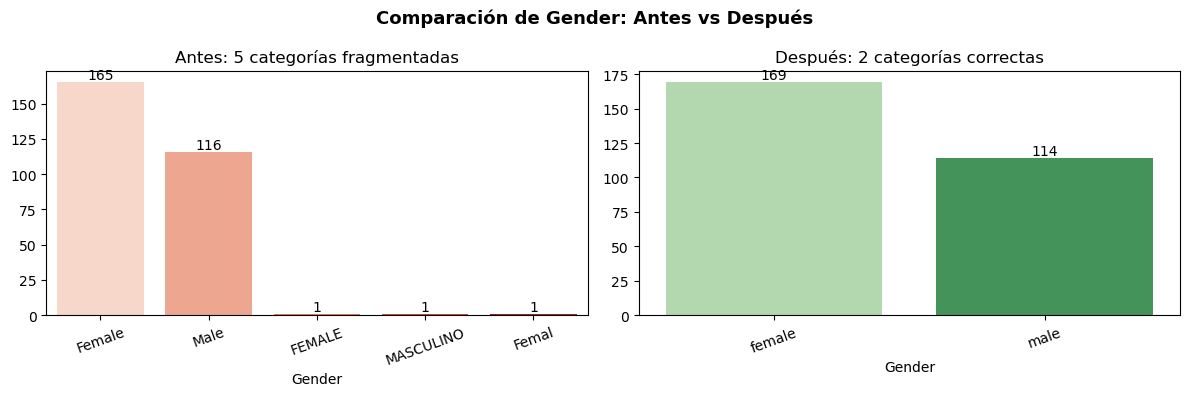

In [47]:
# Comparación de columna 'Gender' (antes vs después)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparación de Gender: Antes vs Después", fontsize=13, fontweight="bold")

# Antes
conteo_antes = df_original["Gender"].value_counts()
ax0 = sns.barplot(
    x=conteo_antes.index, y=conteo_antes.values, ax=axes[0], palette="Reds"
)
for c in ax0.containers:
    ax0.bar_label(c, fmt="%.0f")
axes[0].set_title("Antes: 5 categorías fragmentadas")
axes[0].tick_params(axis="x", rotation=20)

# Después
conteo_despues = df["Gender"].value_counts()
ax1 = sns.barplot(
    x=conteo_despues.index, y=conteo_despues.values, ax=axes[1], palette="Greens"
)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f")
axes[1].set_title("Después: 2 categorías correctas")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("comparacion_gender.png", dpi=100)
plt.show()

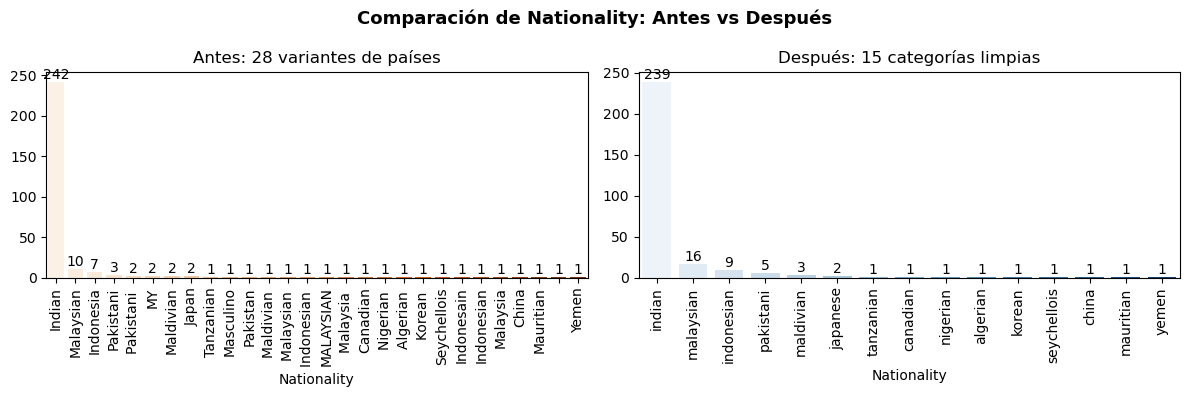

In [48]:
# Comparación de columna 'Nationality' (antes vs después)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparación de Nationality: Antes vs Después", fontsize=13, fontweight="bold")

# Antes
conteo_nat_antes = df_original["Nationality"].value_counts()
ax0 = sns.barplot(
    x=conteo_nat_antes.index, y=conteo_nat_antes.values, ax=axes[0], palette="Oranges"
)
for c in ax0.containers:
    ax0.bar_label(c, fmt="%.0f")
axes[0].set_title("Antes: 28 variantes de países")
axes[0].tick_params(axis="x", rotation=90)

# Después
conteo_nat_despues = df["Nationality"].value_counts()
ax1 = sns.barplot(
    x=conteo_nat_despues.index,
    y=conteo_nat_despues.values,
    ax=axes[1],
    palette="Blues",
)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f")
axes[1].set_title("Después: 15 categorías limpias")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("comparacion_nationality.png", dpi=100)
plt.show()

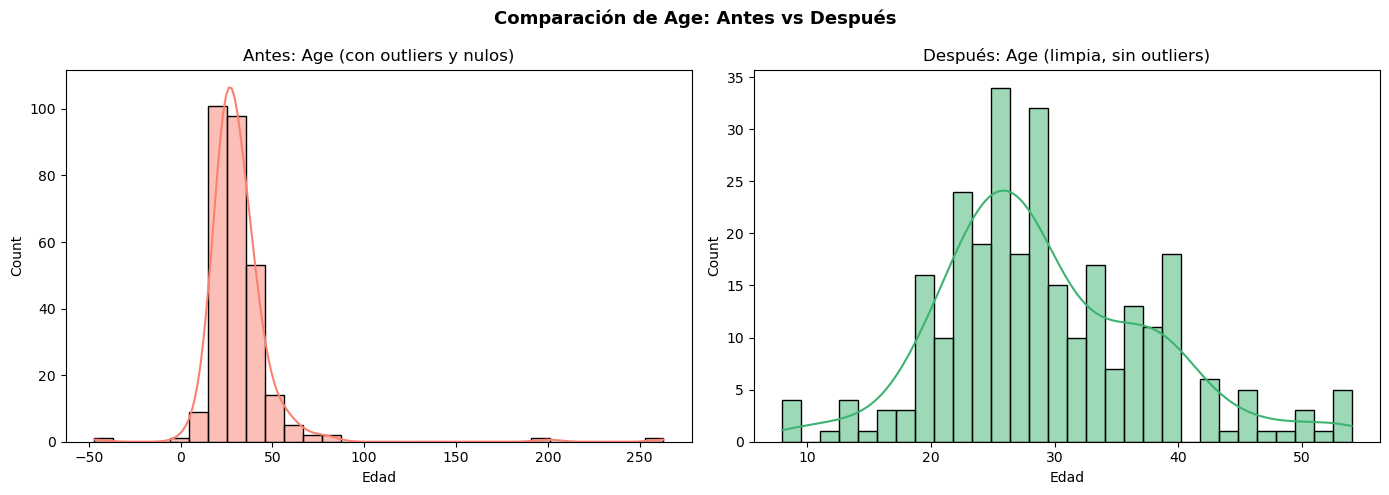

In [49]:
# Comparación de distribución de 'Age' (antes vs después)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de Age: Antes vs Después", fontsize=13, fontweight="bold")

# Antes: distribución del dataset original
sns.histplot(df_original["Age"].dropna(), kde=True, ax=axes[0], color="salmon", bins=30)
axes[0].set_title("Antes: Age (con outliers y nulos)")
axes[0].set_xlabel("Edad")

# Después: distribución limpia
sns.histplot(df["Age"], kde=True, ax=axes[1], color="mediumseagreen", bins=30)
axes[1].set_title("Después: Age (limpia, sin outliers)")
axes[1].set_xlabel("Edad")

plt.tight_layout()
plt.savefig("comparacion_age.png", dpi=100)
plt.show()

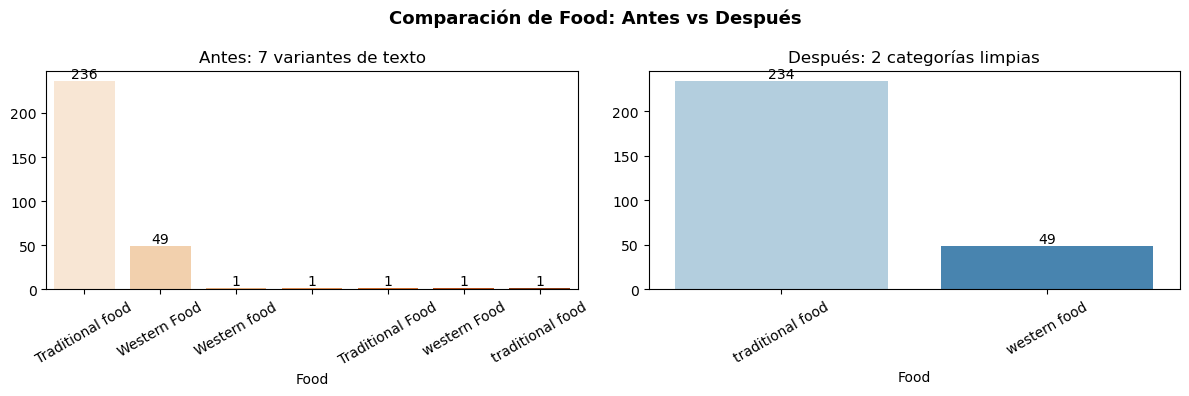

In [50]:
# Comparación de columna 'Food' (antes vs después)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparación de Food: Antes vs Después", fontsize=13, fontweight="bold")

# Antes
conteo_food_antes = df_original["Food"].value_counts()
ax0 = sns.barplot(
    x=conteo_food_antes.index, y=conteo_food_antes.values, ax=axes[0], palette="Oranges"
)
for c in ax0.containers:
    ax0.bar_label(c, fmt="%.0f")
axes[0].set_title("Antes: 7 variantes de texto")
axes[0].tick_params(axis="x", rotation=30)

# Después
conteo_food_despues = df["Food"].value_counts()
ax1 = sns.barplot(
    x=conteo_food_despues.index,
    y=conteo_food_despues.values,
    ax=axes[1],
    palette="Blues",
)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f")
axes[1].set_title("Después: 2 categorías limpias")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("comparacion_food.png", dpi=100)
plt.show()

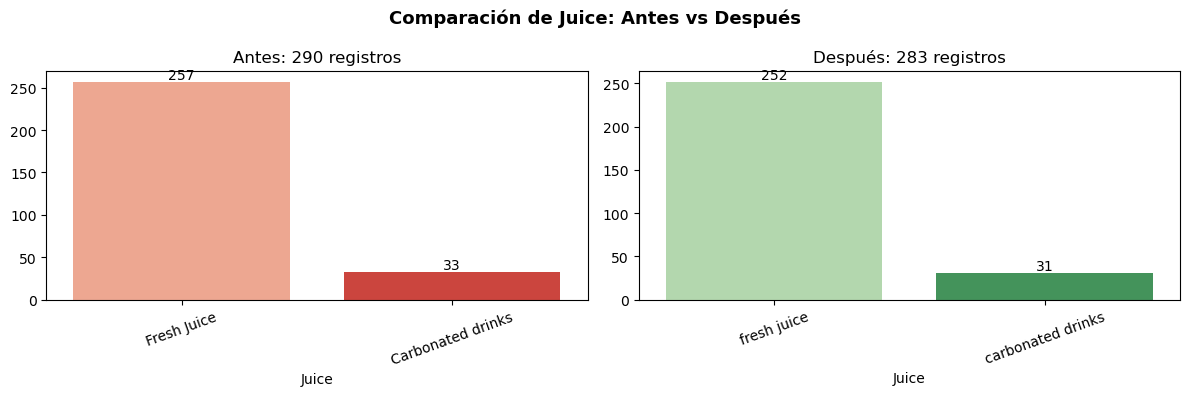

In [51]:
# Comparación de columna 'Juice' (antes vs después)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparación de Juice: Antes vs Después", fontsize=13, fontweight="bold")

# Antes
conteo_antes = df_original["Juice"].value_counts()
ax0 = sns.barplot(
    x=conteo_antes.index, y=conteo_antes.values, ax=axes[0], palette="Reds"
)
for c in ax0.containers:
    ax0.bar_label(c, fmt="%.0f")
axes[0].set_title("Antes: 290 registros")
axes[0].tick_params(axis="x", rotation=20)

# Después
conteo_despues = df["Juice"].value_counts()
ax1 = sns.barplot(
    x=conteo_despues.index, y=conteo_despues.values, ax=axes[1], palette="Greens"
)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f")
axes[1].set_title("Después: 283 registros")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("comparacion_juice.png", dpi=100)
plt.show()

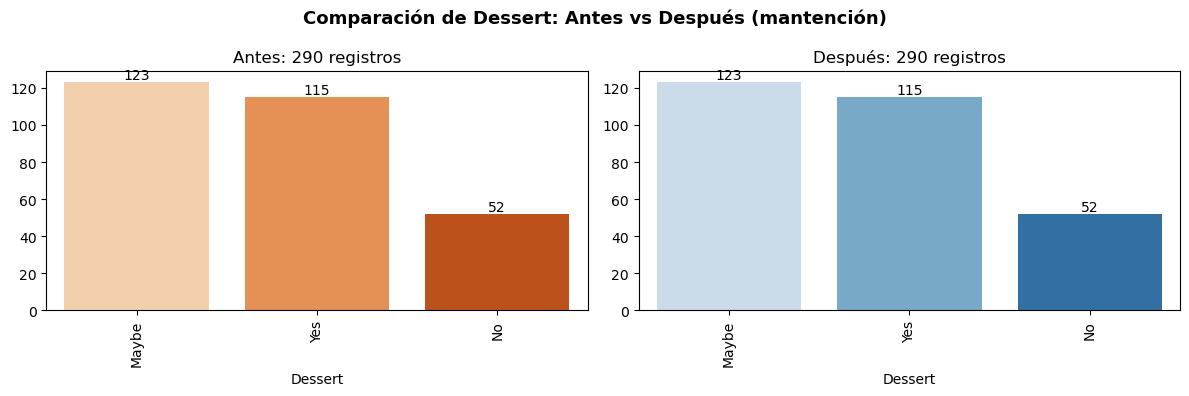

In [52]:
# Comparación de columna 'Dessert' (antes vs después)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Comparación de Dessert: Antes vs Después (mantención)", fontsize=13, fontweight="bold")

# Antes
conteo_antes = df_original["Dessert"].value_counts()
ax0 = sns.barplot(
    x=conteo_antes.index, y=conteo_antes.values, ax=axes[0], palette="Oranges"
)
for c in ax0.containers:
    ax0.bar_label(c, fmt="%.0f")
axes[0].set_title("Antes: 290 registros")
axes[0].tick_params(axis="x", rotation=90)

# Después
conteo_despues = df["Dessert"].value_counts()
ax1 = sns.barplot(
    x=conteo_antes.index,
    y=conteo_antes.values,
    ax=axes[1],
    palette="Blues",
)
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f")
axes[1].set_title("Después: 290 registros")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("comparacion_dessert.png", dpi=100)
plt.show()

## 6. Exportación

Con el DataFrame listo, las comparaciones chequeadas y sin más modificaciones necesarias, podemos exportar el dataset para futuras implementaciones.

In [54]:
# Guardar dataset limpio
# Utilizamos index=False para evitar que Pandas incluya el índice como columna adicional

df.to_csv("../data/processed/food_preference_limpio.csv", index=False)



---

## Conclusiones Generales


1. Sobre la calidad:
El dataset presentó una calidad inicial baja en sus variables de texto, esperable con instrumentos de recolección manual (escritura del sujeto). Las columnas `Gender`, `Nationality` y `Food` contenían múltiples variantes para una misma categoría. La variable `Age`, por su parte, incluía valores negativos y superiores a 200 años, lo que evidencia errores en el proceso de recolección. En contraste, `Juice` y `Dessert` resultaron ser las columnas más limpias del dataset.

2. Sobre las decisiones de limpieza: Optamos por eliminar las columnas `Timestamp` y `Participant_ID` por no aportar valor analítico, lo que elevó el conteo de duplicados de 2 a 83 registros. Esto nos hizo tener cuidado al momento de hacer la limpieza de duplicados, demostrando la importancia de estar atentos durante todo el proceso de trabajo. Para los outliers de `Age`, se aplicó una estrategia de dos etapas, guiados por los rangos del IQR, priorizando la conservación de la muestra. Los valores nulos de las variables categóricas fueron imputados con la moda para no reducir innecesariamente el tamaño del dataset.
3. Sobre el dataset resultante: El dataset final quedó conformado por 6 variables limpias y consistentes con categorías unificadas y sin valores nulos. La transformación mediante `StandardScaler` y `OneHotEncoder` dejó los datos en un formato apto para etapas posteriores de modelado o análisis.
4. Sobre las limitaciones identificadas: Al ser de tamaño reducido (290 registros) y concentrar la gran mayoría de sus participantes en una sola nacionalidad (apróximadamente un 83% de India), la representatividad de los análisis cruzados por nacionalidad se ven limitados. Lo ideal sería contar con una muestra más equilibrada o representativa equitativamente de distintas nacionalidades a futuro.